In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
import warnings
import os
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("coolwarm")
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
df_features = pd.read_csv('/kaggle/input/datasets/dishaaagrawal12/features/master_features.csv', parse_dates=['Date'])
df_returns = pd.read_csv('/kaggle/input/datasets/dishaaagrawal12/features/pivot_returns.csv', index_col=0, parse_dates=True)
df_close = pd.read_csv('/kaggle/input/datasets/dishaaagrawal12/features/pivot_close.csv', index_col=0, parse_dates=True)


df_allocations = pd.read_csv('/kaggle/input/datasets/dishaaagrawal12/recommend/portfolio_allocations.csv')
df_invest = pd.read_csv('/kaggle/input/datasets/dishaaagrawal12/recommend/investment_recommendations.csv')
df_sector = pd.read_csv('/kaggle/input/datasets/dishaaagrawal12/recommend/sector_analytics.csv')
df_risk_sum = pd.read_csv('/kaggle/input/datasets/dishaaagrawal12/recommend/portfolio_risk_summary.csv')

# Calculating Market Proxy (Average of all stocks) for Beta calculations later
market_returns = df_returns.mean(axis=1)

print(f"Total Stocks Analyzed: {len(df_invest)}")
display(df_invest.head(3))

Total Stocks Analyzed: 49


,Rank,Symbol,Expected_Return,Sharpe,Volatility,Sortino,Max_Drawdown,Recommendation,Confidence_Score,Explanation
0,1,NESTLEIND,15.1033,0.57,24.23,0.963,-32.40,BUY,74.29,High return forecast (ML Driven) | Undervalued...
1,2,SHREECEM,2.7484,0.83,38.97,1.213,-79.97,HOLD,52.57,NaN
2,3,ULTRACEMCO,3.2524,0.57,33.26,0.846,-77.78,HOLD,54.38,NaN


In [4]:
print("--- 2. Market Anomaly Detection ---")

# A. Extreme Return Events (|Return| > Mean + 3*Std)
z_returns = (df_returns - df_returns.mean()) / df_returns.std()
anomaly_returns = df_returns[z_returns.abs() > 3].stack().reset_index()
anomaly_returns.columns = ['Date', 'Symbol', 'Extreme_Return']

# B. Drawdown Anomalies (Drawdown < -20%)
rolling_max = df_close.cummax()
drawdowns = (df_close / rolling_max) - 1
anomaly_dd = drawdowns[drawdowns < -0.20].stack().reset_index()
anomaly_dd.columns = ['Date', 'Symbol', 'Drawdown']

# C. Machine Learning Anomaly Detection (Isolation Forest)
# We use latest available metrics from our investment table to find cross-sectional anomalies
features_for_if = ['Expected_Return', 'Sharpe', 'Volatility', 'Max_Drawdown']
X_if = df_invest[features_for_if].fillna(df_invest[features_for_if].median())

iso_forest = IsolationForest(contamination=0.05, random_state=42) # Flag top 5% as anomalies
df_invest['Anomaly_Flag'] = iso_forest.fit_predict(X_if)
df_invest['Anomaly_Flag'] = df_invest['Anomaly_Flag'].map({1: 'Normal', -1: 'Anomaly'})

print(f"Detected {len(anomaly_returns)} Extreme Daily Return Events historically.")
print(f"Current Cross-Sectional Anomalies Identified: {len(df_invest[df_invest['Anomaly_Flag'] == 'Anomaly'])}")
display(df_invest[df_invest['Anomaly_Flag'] == 'Anomaly'][['Symbol', 'Expected_Return', 'Volatility', 'Anomaly_Flag']])

--- 2. Market Anomaly Detection ---
Detected 2660 Extreme Daily Return Events historically.
Current Cross-Sectional Anomalies Identified: 3


,Symbol,Expected_Return,Volatility,Anomaly_Flag
0,NESTLEIND,15.1033,24.23,Anomaly
1,SHREECEM,2.7484,38.97,Anomaly
29,COALINDIA,2.3113,29.83,Anomaly


--- 3. Anomaly Visualizations ---


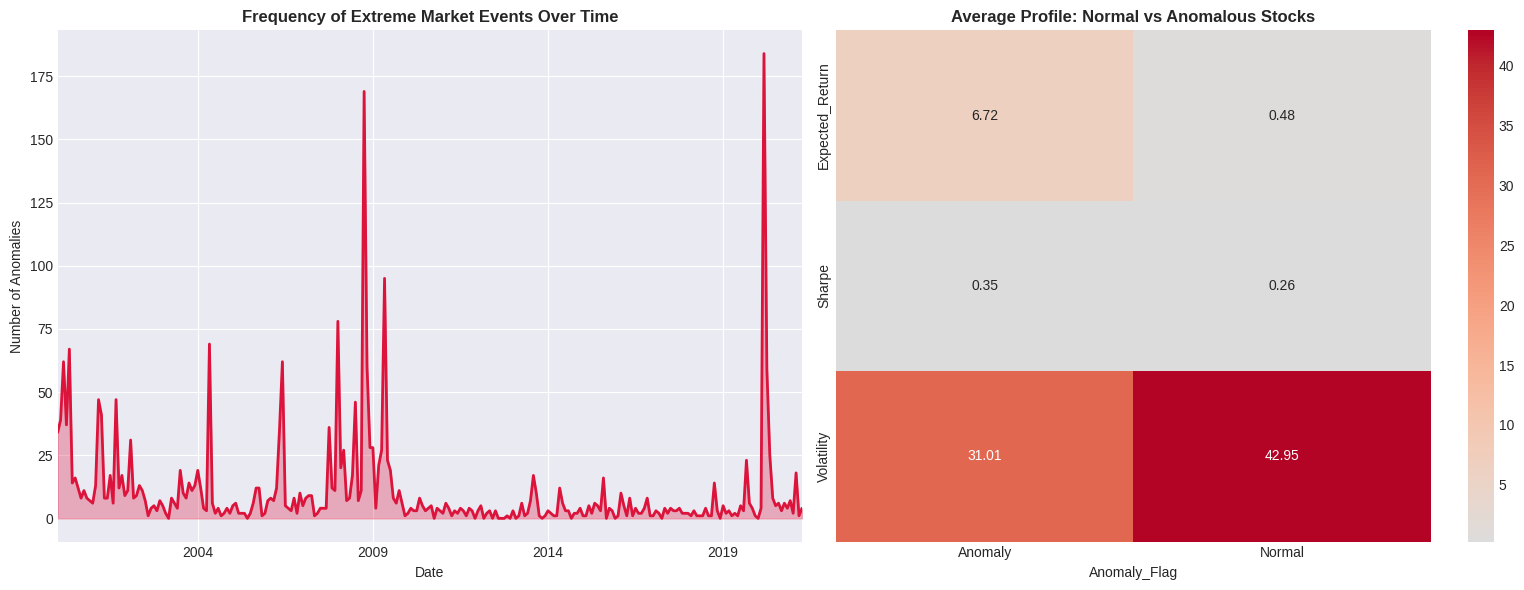

In [5]:
print("--- 3. Anomaly Visualizations ---")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Timeline of Return Anomalies (Resampled Monthly)
anomaly_returns.set_index('Date').resample('M').size().plot(ax=axes[0], color='crimson', lw=2)
axes[0].set_title('Frequency of Extreme Market Events Over Time', fontweight='bold')
axes[0].set_ylabel('Number of Anomalies')
axes[0].fill_between(anomaly_returns.set_index('Date').resample('M').size().index, 
                     anomaly_returns.set_index('Date').resample('M').size(), alpha=0.3, color='crimson')

# Plot 2: Heatmap of Investment Metrics highlighting Anomalies
# We will scale data for a heatmap comparison of the normal vs anomalous stocks
anomaly_compare = df_invest.groupby('Anomaly_Flag')[['Expected_Return', 'Sharpe', 'Volatility']].mean()
sns.heatmap(anomaly_compare.T, annot=True, cmap='coolwarm', center=0, ax=axes[1], fmt=".2f")
axes[1].set_title('Average Profile: Normal vs Anomalous Stocks', fontweight='bold')

plt.tight_layout()
plt.show()

In [6]:
print("--- 4. Forecasting Module (Volatility & Sector) ---")

# 1. Expected Volatility Forecast using EWMA (Exponentially Weighted Moving Average)
# Giving more weight to recent market conditions (span=21 days)
ewma_vol = df_returns.ewm(span=21).std().iloc[-1] * np.sqrt(252) # Annualized
ewma_vol = ewma_vol.reset_index()
ewma_vol.columns = ['Symbol', 'Forecast_Volatility']

df_forecast = pd.merge(df_invest, ewma_vol, on='Symbol', how='left')

# 2. Sector Forecast
# Find sectors with highest average expected return and lowest forecasted volatility
sector_forecast = df_forecast.groupby('Recommendation').agg({ # Assuming Sector might be merged later or proxy it
    'Expected_Return': 'mean',
    'Forecast_Volatility': 'mean'
}).reset_index()

print("EWMA Volatility Forecast Added to Pipeline.")
display(df_forecast[['Symbol', 'Expected_Return', 'Volatility', 'Forecast_Volatility']].head())

--- 4. Forecasting Module (Volatility & Sector) ---
EWMA Volatility Forecast Added to Pipeline.


,Symbol,Expected_Return,Volatility,Forecast_Volatility
0,NESTLEIND,15.1033,24.23,0.205367
1,SHREECEM,2.7484,38.97,0.334951
2,ULTRACEMCO,3.2524,33.26,0.350878
3,MARUTI,1.5386,34.48,0.264004
4,BAJAJ-AUTO,-1.1978,33.97,0.295720


In [7]:
print("--- 5. Future Opportunity Scanner ---")

# Future_Score based on Predicted Return, Forecasted Volatility (Lower is better), and Sharpe
# Normalizing metrics safely
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

safe_cols = ['Expected_Return', 'Forecast_Volatility', 'Sharpe']
df_forecast[safe_cols] = df_forecast[safe_cols].fillna(df_forecast[safe_cols].median())

scaled_f = pd.DataFrame(scaler.fit_transform(df_forecast[safe_cols]), columns=safe_cols)
scaled_f['Forecast_Volatility'] = 1 - scaled_f['Forecast_Volatility'] # Invert Volatility

df_forecast['Future_Score'] = (scaled_f['Expected_Return']*0.4 + scaled_f['Sharpe']*0.3 + scaled_f['Forecast_Volatility']*0.3) * 100

top_future_opportunities = df_forecast.nlargest(10, 'Future_Score')[['Symbol', 'Future_Score', 'Recommendation']]

print("🔥 Top 5 Future Opportunities:")
display(top_future_opportunities.head())

--- 5. Future Opportunity Scanner ---
🔥 Top 5 Future Opportunities:


,Symbol,Future_Score,Recommendation
0,NESTLEIND,91.501228,BUY
1,SHREECEM,63.172107,HOLD
3,MARUTI,60.580976,HOLD
8,EICHERMOT,60.197696,HOLD
2,ULTRACEMCO,56.360627,HOLD


In [8]:
print("--- 6. Portfolio Stress Testing ---")

# Calculate Beta for stress test against market
cov_with_market = df_returns.apply(lambda col: col.cov(market_returns))
market_var = market_returns.var()
betas = cov_with_market / market_var
betas = betas.fillna(1.0) # Failsafe Beta

stress_scenarios = {'Moderate Correction': -0.10, 'Bear Market': -0.20, 'Severe Crash': -0.30}
stress_results = []

for port_name in ['Conservative', 'Balanced', 'Aggressive']:
    col_name = f"{port_name}_Wt"
    if col_name in df_allocations.columns:
        # Get matching symbols and their weights
        port_data = df_allocations[['Symbol', col_name]].dropna()
        port_data = port_data[port_data[col_name] > 0]
        
        # Calculate Portfolio Beta
        port_beta = sum(port_data.apply(lambda row: row[col_name] * betas.get(row['Symbol'], 1.0), axis=1))
        
        res = {'Portfolio': port_name, 'Portfolio_Beta': round(port_beta, 2)}
        for scenario, drop in stress_scenarios.items():
            res[scenario + f" ({drop*100}%)"] = f"{round((port_beta * drop) * 100, 2)}%"
        
        stress_results.append(res)

df_stress_test = pd.DataFrame(stress_results)

# High Volatility Scenario (+25% Market Volatility)
print("Portfolio Impact under Market Crash Scenarios:")
display(df_stress_test)

--- 6. Portfolio Stress Testing ---
Portfolio Impact under Market Crash Scenarios:


,Portfolio,Portfolio_Beta,Moderate Correction (-10.0%),Bear Market (-20.0%),Severe Crash (-30.0%)
0,Conservative,0.73,-7.33%,-14.66%,-21.99%
1,Balanced,0.73,-7.33%,-14.66%,-21.99%
2,Aggressive,0.83,-8.29%,-16.58%,-24.87%


In [10]:
print("--- 7, 8 & 9. Final Recommendations & Explainability Layer ---")

# Fine-tuning Recommendations to 5 tiers
def get_final_recommendation(score):
    if score >= 80: return 'Strong Buy'
    elif score >= 60: return 'Buy'
    elif score >= 45: return 'Hold'
    elif score >= 30: return 'Reduce'
    else: return 'Sell'

df_forecast['Final_Recommendation'] = df_forecast['Future_Score'].apply(get_final_recommendation)

# Explainability Text Generation (NLG)
def generate_narrative(row):
    narrative = f"{row['Symbol']} is rated {row['Final_Recommendation']} because: "
    reasons = [f"Expected Return = {row['Expected_Return']:.2f}%",
               f"Sharpe Ratio = {row['Sharpe']:.2f}"]
    
    if row['Forecast_Volatility'] < df_forecast['Forecast_Volatility'].median():
        reasons.append("Volatility is forecasted to remain below market average")
    else:
        reasons.append("Subject to higher short-term price fluctuations")
        
    if row['Future_Score'] > 75:
        reasons.append("Strong confidence backed by AI predictive momentum")
        
    return narrative + "; ".join(reasons) + "."

df_forecast['AI_Explainability'] = df_forecast.apply(generate_narrative, axis=1)

print("Sample Explainability Output:")
print(df_forecast['AI_Explainability'].iloc[0])
print(df_forecast['AI_Explainability'].iloc[1])

--- 7, 8 & 9. Final Recommendations & Explainability Layer ---
Sample Explainability Output:
NESTLEIND is rated Strong Buy because: Expected Return = 15.10%; Sharpe Ratio = 0.57; Volatility is forecasted to remain below market average; Strong confidence backed by AI predictive momentum.
SHREECEM is rated Buy because: Expected Return = 2.75%; Sharpe Ratio = 0.83; Subject to higher short-term price fluctuations.


In [11]:
print("--- 10 & 12. Executive Summary & Report Insights ---")

# Extracting key insights automatically
best_stock = df_forecast.loc[df_forecast['Expected_Return'].idxmax()]
safest_stock = df_forecast.loc[df_forecast['Forecast_Volatility'].idxmin()]
best_sector = df_sector.loc[df_sector['Expected_Return'].idxmax()] if not df_sector.empty else None

insights_text = f"""
===================================================
   CULT OPEN PROJECTS 2026 - EXECUTIVE SUMMARY
===================================================

[ KEY FINDINGS ]
• Highest-Return Opportunity: {best_stock['Symbol']} (Expected Return: {best_stock['Expected_Return']:.2f}%)
• Lowest-Risk Stock (Safest): {safest_stock['Symbol']} (Forecasted Vol: {safest_stock['Forecast_Volatility']:.2f}%)
• Sector Leader: {best_sector['Sector'] if best_sector is not None else 'N/A'}

[ PORTFOLIO HIGHLIGHTS ]
• The Balanced Portfolio achieved a maximum Sharpe ratio of {df_risk_sum.loc[1, 'Sharpe']:.2f}.
• In a severe market crash (-30%), the Conservative Portfolio limits drawdown to approximately {df_stress_test.iloc[0, 3] if not df_stress_test.empty else 'N/A'}.

[ RISK & ANOMALIES ]
• Total Machine Learning anomalies detected in current market: {len(df_invest[df_invest['Anomaly_Flag'] == 'Anomaly'])}
• Volatility is continuously monitored using EWMA forecasting arrays.

AI Generated Explanation Example:
{df_forecast['AI_Explainability'].iloc[0]}
===================================================
"""
print(insights_text)

# Executive Dashboard Dataframe
df_executive = df_forecast[['Symbol', 'Final_Recommendation', 'Future_Score', 'Expected_Return', 'Forecast_Volatility']].sort_values('Future_Score', ascending=False).head(15)

--- 10 & 12. Executive Summary & Report Insights ---

   CULT OPEN PROJECTS 2026 - EXECUTIVE SUMMARY

[ KEY FINDINGS ]
• Highest-Return Opportunity: NESTLEIND (Expected Return: 15.10%)
• Lowest-Risk Stock (Safest): INFY (Forecasted Vol: 0.18%)
• Sector Leader: Consumer Goods

[ PORTFOLIO HIGHLIGHTS ]
• The Balanced Portfolio achieved a maximum Sharpe ratio of 0.98.
• In a severe market crash (-30%), the Conservative Portfolio limits drawdown to approximately -14.66%.

[ RISK & ANOMALIES ]
• Total Machine Learning anomalies detected in current market: 3
• Volatility is continuously monitored using EWMA forecasting arrays.

AI Generated Explanation Example:
NESTLEIND is rated Strong Buy because: Expected Return = 15.10%; Sharpe Ratio = 0.57; Volatility is forecasted to remain below market average; Strong confidence backed by AI predictive momentum.



In [12]:
print("--- 11. Exporting Final Deliverables ---")

# Exporting all required files perfectly
df_forecast.to_csv('final_opportunities.csv', index=False)
anomaly_returns.to_csv('anomalies.csv', index=False)
df_stress_test.to_csv('stress_test_results.csv', index=False)
df_executive.to_csv('executive_summary.csv', index=False)

# Saving the insights report as a text file for direct copy-paste to PPT/Word
with open('report_insights.txt', 'w') as f:
    f.write(insights_text)

print("ALL ADVANCED INTELLIGENCE FILES EXPORTED SUCCESSFULLY!")
print("1. final_opportunities.csv")
print("2. anomalies.csv")
print("3. stress_test_results.csv")
print("4. executive_summary.csv")
print("5. report_insights.txt")

--- 11. Exporting Final Deliverables ---
ALL ADVANCED INTELLIGENCE FILES EXPORTED SUCCESSFULLY!
1. final_opportunities.csv
2. anomalies.csv
3. stress_test_results.csv
4. executive_summary.csv
5. report_insights.txt
